In [15]:
import jsonlines
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
from Levenshtein import distance as edit_distance
from tqdm import tqdm
from collections import defaultdict
import itertools
import json
from copy import deepcopy

plt.rcParams["figure.dpi"] = 200
plt.rcParams["font.size"] = 16

import os
import sys

sys.path.append(os.path.abspath(".."))

from game import RepeatedReferenceGame, Trial

In [4]:
import spacy

nlp = spacy.load("en_core_web_sm")


def process_message(msg):
    return nlp(msg)


TAGSET = ["NOUN", "ADJ", "VERB", "ADV", "PROPN", "NUM", "PRON", "ADP"]


def wnr(s1, s2):
    if not s1 or not s2:
        return None
    if len(s1) == 0 or len(s2) == 0:
        return None
    s1_content = [t.lemma_.lower() for t in s1 if t.pos_ in TAGSET]
    s2_content = [t.lemma_.lower() for t in s2 if t.pos_ in TAGSET]
    return edit_distance(s1_content, s2_content, weights=(1, 0, 1)) / len(s1)


def wnd(s1, s2):
    if not s1 or not s2:
        return None
    if len(s1) == 0 or len(s2) == 0:
        return None
    s1_content = [t.lemma_.lower() for t in s1 if t.pos_ in TAGSET]
    s2_content = [t.lemma_.lower() for t in s2 if t.pos_ in TAGSET]
    return edit_distance(s1_content, s2_content, weights=(1, 0, 1))


def snd(s):
    s_content = [[t.lemma_.lower() for t in u if t.pos_ in TAGSET] for u in s]
    if len(s_content) == 1:
        return 0
    if isinstance(s_content[0], str):
        return 0
    snd_values = [0 for _ in s_content]
    for i, x in enumerate(s_content):
        for w in x:
            w_count = 0
            for j, y in enumerate(s_content):
                if i == j:
                    continue
                if not w in y:
                    w_count += 1
                    break  # only count the first occurrence of the word
            snd_values[i] += w_count / (len(s) - 1)
        snd_values[i] /= len(s)

    return sum(snd_values) / len(snd_values)

In [5]:
def get_messages_by_target(game):
    messages_by_target = defaultdict(list)
    for t in game["trials"]:
        messages_by_target[t["target"]].append(t["message"])

    return messages_by_target


def get_trials_by_target(game):
    trials_by_target = defaultdict(list)
    for t in game["trials"]:
        trials_by_target[t["target"]].append(t)

    return trials_by_target

In [11]:
dfs_list = list()
for results_file in Path("../results/sampling_gpt").glob("*.jsonl"):
    _df = pd.read_json(
        results_file,
        lines=True,
    )
    preference_function = re.search(r"speaker=([^-]+)", results_file.name).group(1)
    _df["preference_function"] = preference_function
    _df["listener"] = re.search(r"listener=([^-]+)", results_file.name).group(1)
    dfs_list.append(_df)

for results_file in Path("../results/sampling_gemma_eval").glob("*.jsonl"):
    _df = pd.read_json(
        results_file,
        lines=True,
    )
    preference_function = re.search(r"speaker=([^-]+)", results_file.name).group(1)
    _df["preference_function"] = preference_function.replace("_1ep", "")
    _df["listener"] = re.search(r"listener=([^-]+)", results_file.name).group(1)
    dfs_list.append(_df)

df = pd.concat(dfs_list, ignore_index=True)

# Explode the sampled_trials column
df_exploded = df.explode("sampled_trials")

df_exploded["messages"] = df_exploded["sampled_trials"].apply(lambda x: x["message"])

# Apply spacy processing to each message
df_exploded["processed_message"] = list(nlp.pipe(df_exploded["messages"]))
df_exploded["message_length"] = df_exploded["processed_message"].apply(lambda x: len(x))

# Group back to original structure
df["sampled_trials_processed"] = df_exploded.groupby(level=0)[
    "processed_message"
].apply(list)

df["trial_idx"] = df["game"].apply(lambda x: len(x["trials"]))
df["block_idx"] = df.apply(
    lambda x: len(
        get_messages_by_target(x["game"]).get(x["sampled_trials"][0]["target"], [])
    )
    + 1,
    axis=1,
)
df["previous_trial"] = df.apply(
    lambda x: (
        get_trials_by_target(x["game"]).get(x["sampled_trials"][0]["target"], [None])[
            -1
        ]
    ),
    axis=1,
)
df["previous_correct"] = df["previous_trial"].apply(
    lambda x: (
        Trial.model_validate(
            {
                "target": x["target"],
                "message": x["message"],
                "interpretation": {
                    k: -float("inf") if v is None else v
                    for k, v in x["interpretation"].items()
                },
            }
        ).get_correct()
        if x is not None and x["interpretation"] is not None
        else None
    )
)
df["previous_message"] = df.apply(
    lambda x: get_messages_by_target(x["game"]).get(
        x["sampled_trials"][0]["target"], [None]
    )[-1],
    axis=1,
)
# Filter out None values and keep track of indices
valid_messages = [
    (i, msg) for i, msg in enumerate(df["previous_message"]) if msg is not None
]
indices, messages = zip(*valid_messages) if valid_messages else ([], [])

# Process valid messages
processed_messages = list(nlp.pipe(messages)) if messages else []

# Create list of None/processed messages in original order
processed_previous = [None] * len(df)
for i, processed_msg in zip(indices, processed_messages):
    processed_previous[i] = processed_msg

df["processed_previous_message"] = processed_previous

df["wnr"] = df.apply(
    lambda x: [
        wnr(x["processed_previous_message"], m) for m in x["sampled_trials_processed"]
    ],
    axis=1,
)

df["wnd"] = df.apply(
    lambda x: [
        wnd(x["processed_previous_message"], m) for m in x["sampled_trials_processed"]
    ],
    axis=1,
)

df["snd"] = df.apply(
    lambda x: snd(x["sampled_trials_processed"]),
    axis=1,
)

df_exploded = df.explode(
    ["sampled_trials", "sampled_trials_processed", "wnr", "wnd"]
).reset_index(drop=True)
df_exploded["message_length"] = df_exploded["sampled_trials_processed"].apply(len)

df_exploded["sampled_trials"] = df_exploded["sampled_trials"].apply(
    lambda x: {
        "target": x["target"],
        "message": x["message"],
        "interpretation": (
            {
                k: -float("inf") if v is None else v
                for k, v in x["interpretation"].items()
            }
            if x["interpretation"] is not None
            else None
        ),
    }
)

df_exploded["listener_prob"] = df_exploded["sampled_trials"].apply(
    lambda x: (
        np.exp(x["interpretation"][x["target"]])
        if isinstance(x, dict) and x["interpretation"] is not None
        else None
    )
)
df_exploded["correct"] = df_exploded["sampled_trials"].apply(
    lambda x: (
        Trial.model_validate(x).get_correct()
        if isinstance(x, dict) and x["interpretation"] is not None
        else None
    )
)

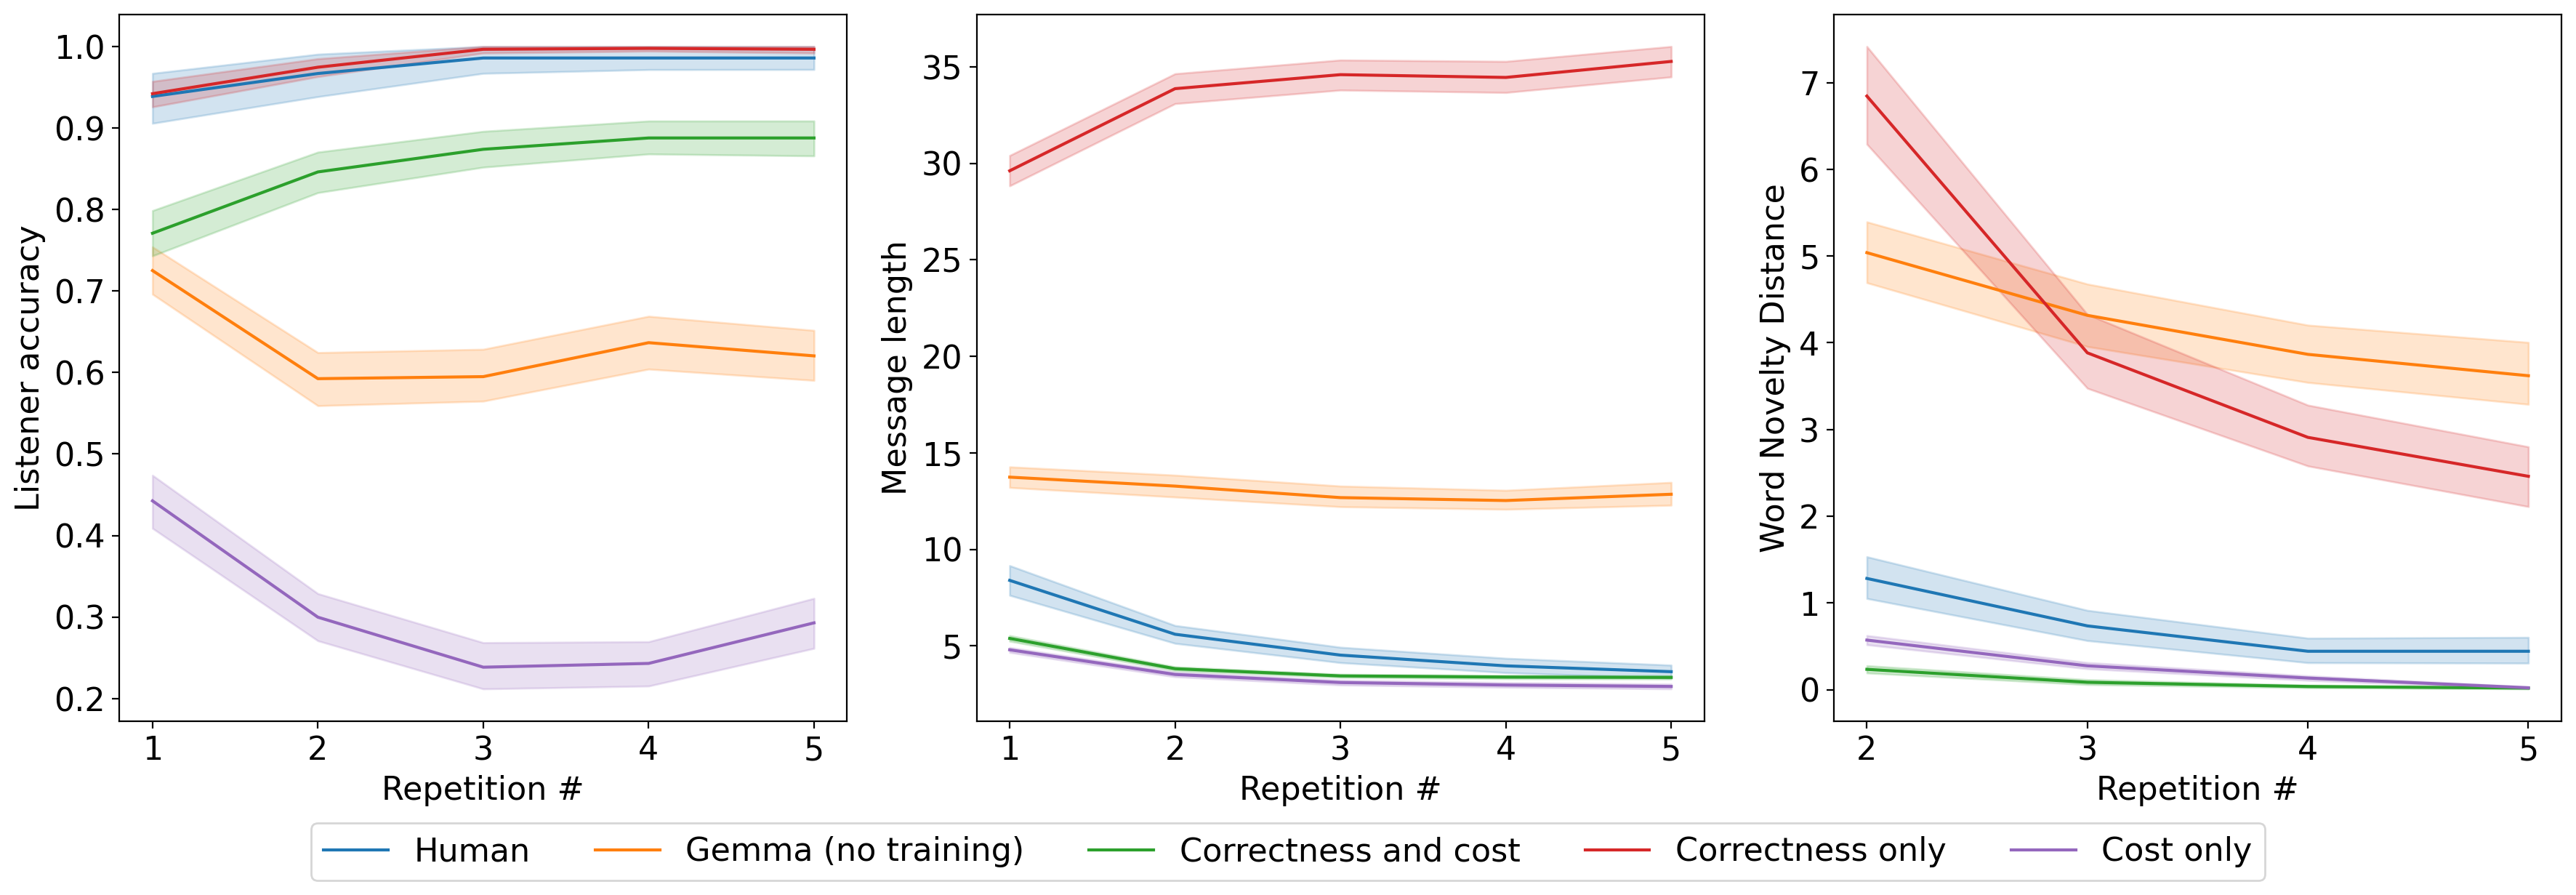

In [16]:
df_plot_gpt = (
    df_exploded[df_exploded.listener == "gpt"]
    .copy()
    .reset_index()
    .rename(
        columns={
            "correct": "Listener accuracy",
            "wnd": "Word Novelty Distance",
            "message_length": "Message length",
            "preference_function": "Speaker",
            "block_idx": "Repetition #",
        }
    )
    .replace(
        {
            "Speaker": {
                "human": "Human",
                "gemma_pt": "Gemma (no training)",
                "hard_correctness_or_cost": "Correctness and cost",
                "hard_correctness": "Correctness only",
                "cost": "Cost only",
            }
        }
    )
)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

sns.lineplot(
    data=df_plot_gpt,
    x="Repetition #",
    y="Message length",
    hue="Speaker",
    ax=ax2,
    hue_order=[
        "Human",
        "Gemma (no training)",
        "Correctness and cost",
        "Correctness only",
        "Cost only",
    ],
)
ax2.get_legend().remove()
ax2.set_xticks(range(1, 6))

sns.lineplot(
    data=df_plot_gpt,
    x="Repetition #",
    y="Listener accuracy",
    hue="Speaker",
    ax=ax1,
    hue_order=[
        "Human",
        "Gemma (no training)",
        "Correctness and cost",
        "Correctness only",
        "Cost only",
    ],
)
ax1.get_legend().remove()
ax1.set_xticks(range(1, 6))

sns.lineplot(
    data=df_plot_gpt,
    x="Repetition #",
    y="Word Novelty Distance",
    hue="Speaker",
    ax=ax3,
    hue_order=[
        "Human",
        "Gemma (no training)",
        "Correctness and cost",
        "Correctness only",
        "Cost only",
    ],
)
ax3.get_legend().remove()
ax3.set_xticks(range(2, 6))

# Create a common legend at the bottom
handles, labels = ax3.get_legend_handles_labels()
fig.legend(handles, labels, loc="center", bbox_to_anchor=(0.5, 0.0), ncol=10)

plt.tight_layout()
# Adjust bottom margin to make room for legend
plt.subplots_adjust(bottom=0.15)

plt.savefig("eval-gpt.pdf", dpi=256, bbox_inches="tight")

In [14]:
df_exploded[df_exploded.listener == "gpt"].groupby(
    ["preference_function", "block_idx"]
).agg({"correct": "mean", "message_length": "mean", "wnd": "mean"})

correct  message_length       wnd
preference_function      block_idx                                    
cost                     1          0.442509        4.793981       NaN
                         2          0.299769        3.516204  0.572319
                         3          0.238426        3.098380  0.275344
                         4          0.243056        2.968750  0.134443
                         5          0.292824        2.893519  0.022222
gemma_pt                 1          0.725058       13.739583       NaN
                         2          0.592417       13.275463  5.039443
                         3          0.594907       12.679398  4.316647
                         4          0.636574       12.527778  3.866898
                         5           0.62037       12.853009   3.62037
hard_correctness         1          0.942063       29.612269       NaN
                         2          0.974537       33.868056  6.844907
                         3          0.996528       34.593750  3.884259
                         4          0.997685       34.450231  2.909722
                         5          0.996528       35.278935  2.460648
hard_correctness_or_cost 1          0.770833        5.383102       NaN
                         2          0.846065        3.814815  0.234954
                         3          0.873843        3.440972  0.085648
                         4          0.887731        3.381944  0.037037
                         5          0.887731        3.363426  0.018519
human                    1          0.938679        8.391509       NaN
                         2          0.966825        5.599057  1.283019
                         3          0.985849        4.518868  0.735849
                         4          0.985849        3.962264  0.443396
                         5          0.985849        3.660377  0.443396

In [24]:
hard_correctness_or_cost_df = pd.read_json(
    "../results/preference_pairs_gemma/hard_correctness_or_cost-speaker=gemma_pt-listener=gemma_ft/train.jsonl",
    lines=True,
)
hard_correctness_or_cost_df = hard_correctness_or_cost_df.explode("preference_pairs")
hard_correctness_or_cost_df.preference_pairs.count()

np.int64(11051)

In [27]:
hard_correctness_df = pd.read_json(
    "../results/preference_pairs_gemma/hard_correctness-speaker=gemma_pt-listener=gemma_ft/train.jsonl",
    lines=True,
)
print(len(hard_correctness_df))
hard_correctness_df = hard_correctness_df.explode("preference_pairs")
hard_correctness_df.preference_pairs.count()

4800


np.int64(8534)

In [26]:
cost_df = pd.read_json(
    "../results/preference_pairs_gemma/cost-speaker=gemma_pt-listener=gemma_ft/train.jsonl",
    lines=True,
)
cost_df = cost_df.explode("preference_pairs")
cost_df.preference_pairs.count()

np.int64(10727)

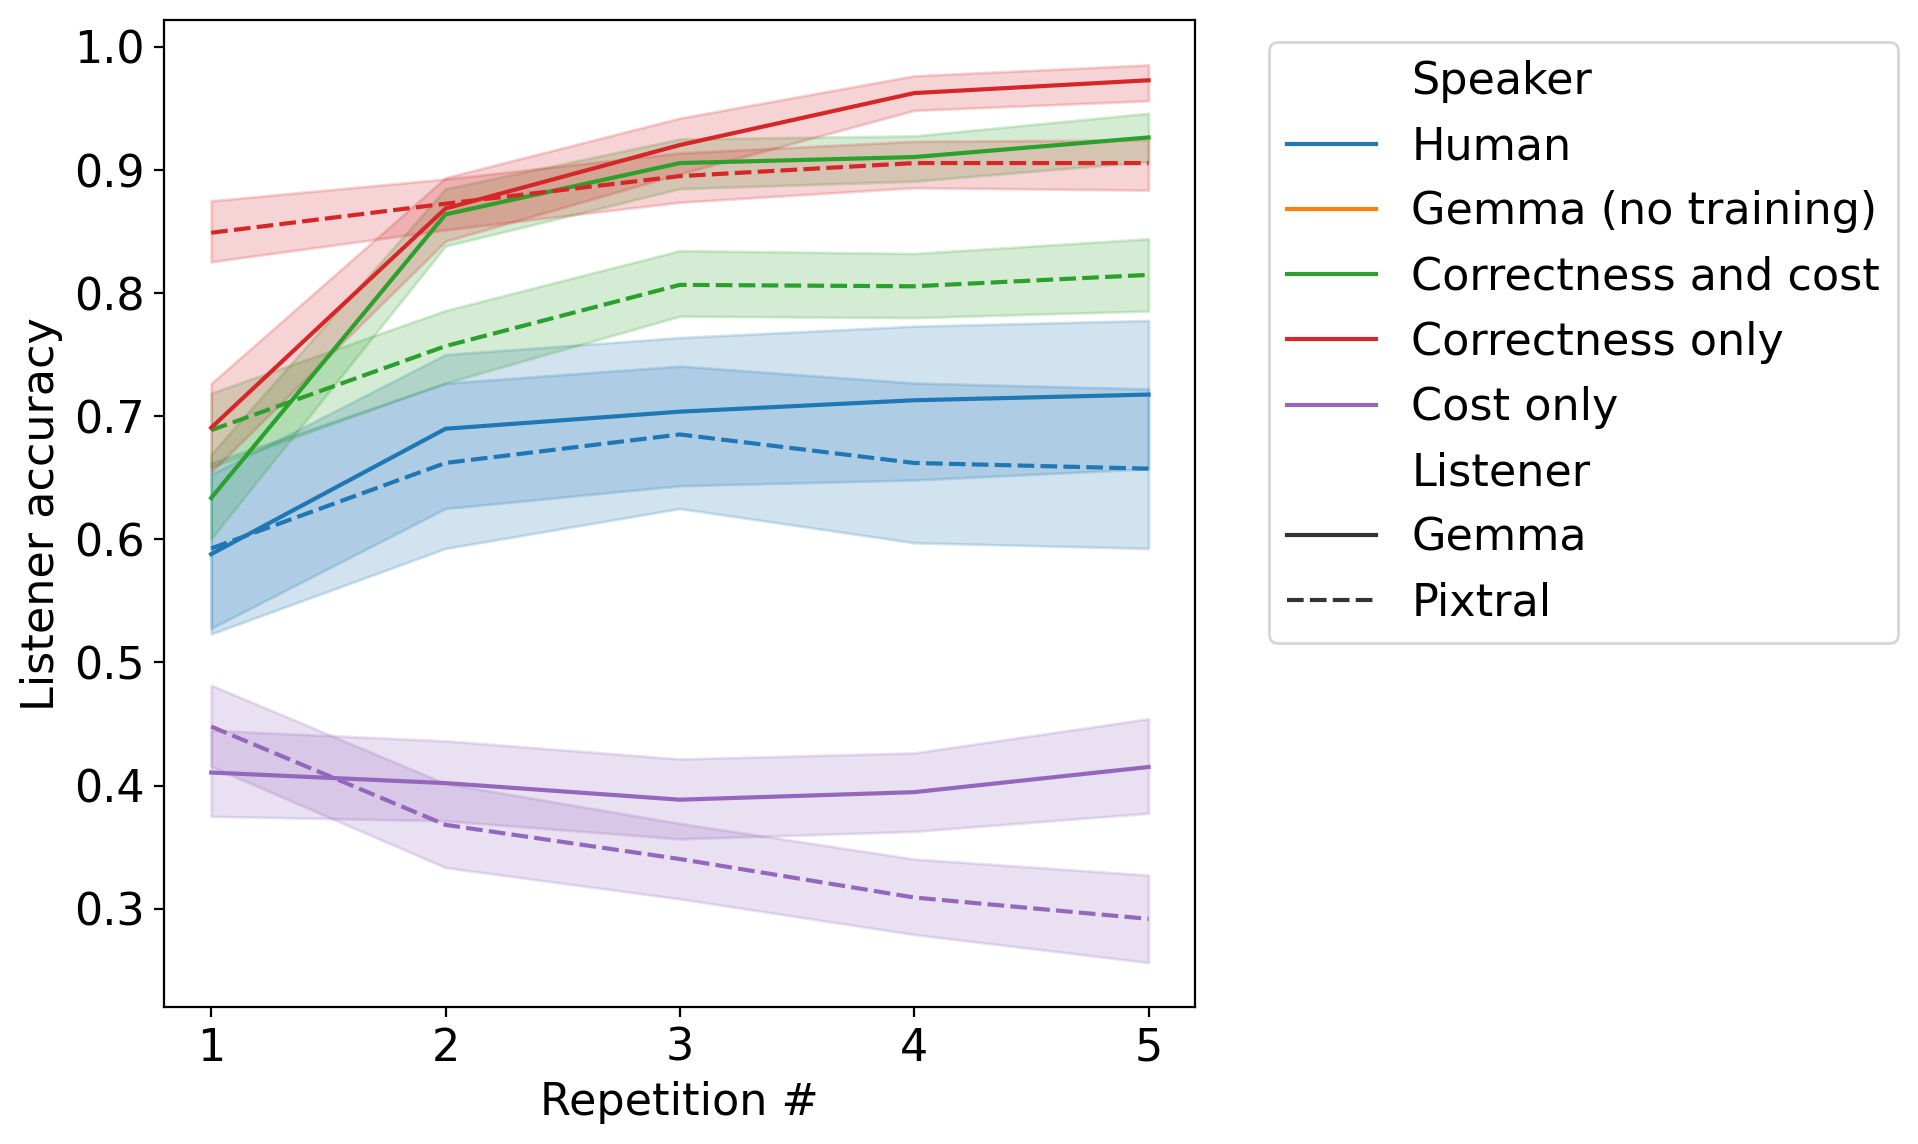

In [29]:
df_plot_other = (
    df_exploded[df_exploded.listener.isin(["gemma_ft", "pixtral_ft"])]
    .copy()
    .reset_index()
    .rename(
        columns={
            "correct": "Listener accuracy",
            "wnd": "Word Novelty Distance",
            "message_length": "Message length",
            "preference_function": "Speaker",
            "block_idx": "Repetition #",
            "listener": "Listener",
        }
    )
    .replace(
        {
            "Speaker": {
                "human": "Human",
                "gemma_pt": "Gemma (no training)",
                "hard_correctness_or_cost": "Correctness and cost",
                "hard_correctness": "Correctness only",
                "cost": "Cost only",
            },
            "Listener": {
                "gemma_ft": "Gemma",
                "pixtral_ft": "Pixtral",
            },
        }
    )
)

fig, ax1 = plt.subplots(1, 1, figsize=(10, 6))

sns.lineplot(
    data=df_plot_other,
    x="Repetition #",
    y="Listener accuracy",
    hue="Speaker",
    ax=ax1,
    hue_order=[
        "Human",
        "Gemma (no training)",
        "Correctness and cost",
        "Correctness only",
        "Cost only",
    ],
    style="Listener",
    style_order=["Gemma", "Pixtral"],
)
ax1.set_xticks(range(1, 6))
ax1.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()

plt.savefig("eval-other.pdf", dpi=256)